In [50]:
import pandas as pd
import numpy as np

# Load dataset
file_path = r"E:\file_main\Major_1\fauna-forecast\data\raw\bison_population_interpolated.csv"
df = pd.read_csv(file_path, parse_dates=['Year'], index_col='Year')

# Ensure sorted
df = df.sort_index()

# Force yearly frequency (year-end)
#df = df.asfreq('YE')

# Log transform
df['Log_Pop'] = np.log1p(df['Population'])

df.head()


,Population,Log_Pop
Year,,
1800-01-01,6.000000e+07,17.909855
1801-01-01,5.933333e+07,17.898682
1802-01-01,5.866667e+07,17.887382
1803-01-01,5.800000e+07,17.875954
1804-01-01,5.733333e+07,17.864393


In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Train: until 2010 | Test: 2011–2017
train = df.loc[:'2010-12-31', 'Log_Pop']
test = df.loc['2011-12-31':'2017-12-31', 'Log_Pop']

print("Train size:", len(train))
print("Test size:", len(test))


Train size: 211
Test size: 6


In [52]:
import pmdarima as pm

# Use auto_arima to find the best (p,d,q) order
auto_model = pm.auto_arima(
    train,
    seasonal=False,       # no seasonality unless you expect it
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    trace=True            # prints candidate models
)

print("Best ARIMA order:", auto_model.order)


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=128.353, Time=2.46 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=141.501, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=129.622, Time=0.12 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=132.470, Time=0.39 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=140.674, Time=0.05 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=126.955, Time=1.12 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=130.981, Time=0.65 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=125.590, Time=0.58 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=126.940, Time=1.44 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=128.669, Time=0.49 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=123.821, Time=0.83 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=131.315, Time=0.17 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=128.310, Time=0.06 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=125.134, Time=0.51 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=125.1

In [53]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA with best order from auto_arima
best_order = auto_model.order
model = ARIMA(train, order=best_order)
model_fit = model.fit()

print(model_fit.summary())


D:\Python\3.11\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
D:\Python\3.11\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
D:\Python\3.11\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Log_Pop   No. Observations:                  211
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -58.910
Date:                Tue, 16 Sep 2025   AIC                            123.821
Time:                        03:45:22   BIC                            133.862
Sample:                    01-01-1800   HQIC                           127.880
                         - 01-01-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8599      0.102      8.418      0.000       0.660       1.060
ma.L1         -0.6965      0.124     -5.635      0.000      -0.939      -0.454
sigma2         0.1025      0.002     48.246      0.0

In [54]:
# MAE, RMSE, MAPE
mae = mean_absolute_error(test_pop, forecast_pop)
rmse = np.sqrt(mean_squared_error(test_pop, forecast_pop))
mape = np.mean(np.abs((test_pop - forecast_pop) / test_pop)) * 100
# Forecast for test length
forecast_log = model_fit.forecast(steps=len(test))

# Back-transform
forecast_pop = np.expm1(forecast_log)
test_pop = np.expm1(test)

# Combine results
forecast_df = pd.DataFrame({
    "Actual_Log": test,
    "Forecast_Log": forecast_log,
    "Actual_Pop": test_pop,
    "Forecast_Pop": forecast_pop
}, index=test.index)

forecast_df.head()

print("Evaluation Metrics:")
print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape, "%")


Evaluation Metrics:
MAE : 57265.19025499492
RMSE: 60235.509963507575
MAPE: 7.958496606065035 %


In [55]:
mae = mean_absolute_error(test_pop, forecast_pop)
rmse = np.sqrt(mean_squared_error(test_pop, forecast_pop))
mape = np.mean(np.abs((test_pop - forecast_pop) / test_pop)) * 100

print("Evaluation Metrics:")
print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape, "%")


Evaluation Metrics:
MAE : 57265.19025499492
RMSE: 60235.509963507575
MAPE: 7.958496606065035 %


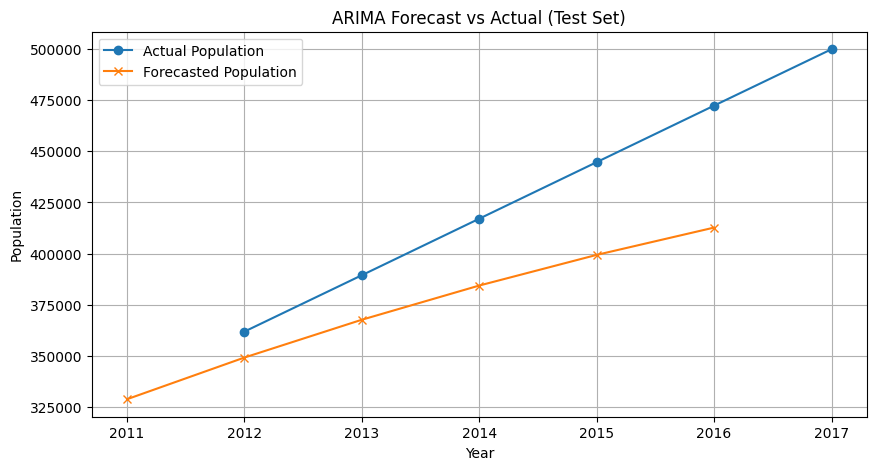

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(test_pop, label='Actual Population', marker='o')
plt.plot(forecast_pop, label='Forecasted Population', marker='x')
plt.title("ARIMA Forecast vs Actual (Test Set)")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.show()


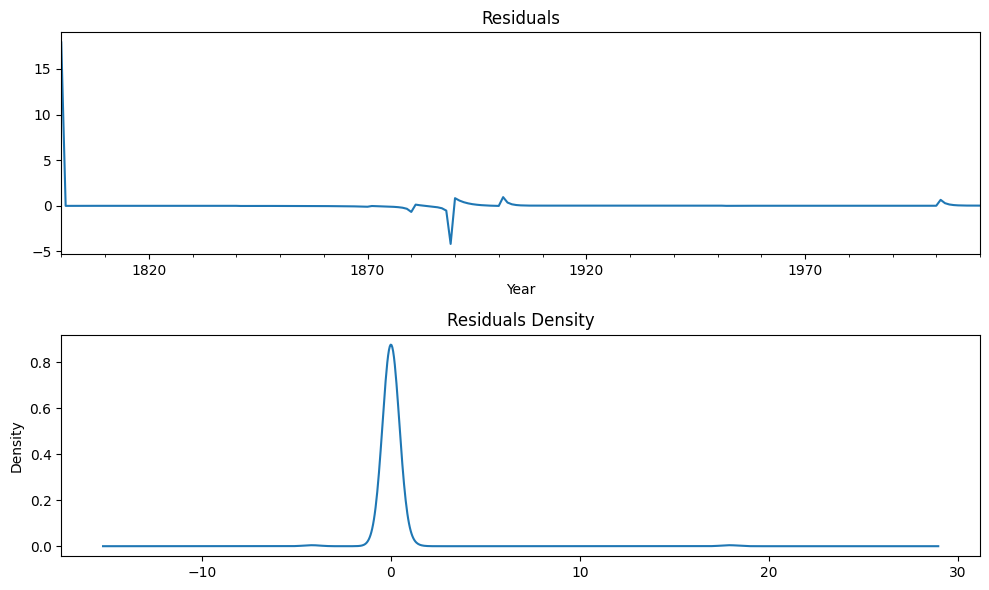

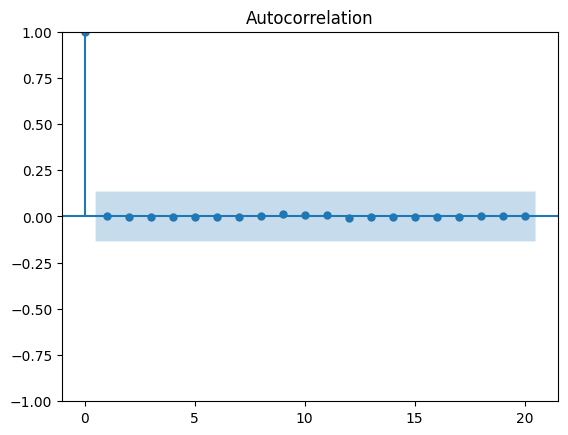

Ljung-Box test result:
     lb_stat  lb_pvalue
10  0.039388        1.0


In [43]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox

# Residuals
residuals = model_fit.resid

# Plot residuals
fig, ax = plt.subplots(2, 1, figsize=(10,6))
residuals.plot(ax=ax[0], title="Residuals")
residuals.plot(kind='kde', ax=ax[1], title="Residuals Density")
plt.tight_layout()
plt.show()

# ACF plot
sm.graphics.tsa.plot_acf(residuals, lags=20)
plt.show()

# Ljung-Box test (H0: residuals are white noise)
ljung_box = acorr_ljungbox(residuals, lags=[10], return_df=True)
print("Ljung-Box test result:")
print(ljung_box)


In [61]:
from statsmodels.tsa.arima.model import ARIMA

# Refit ARIMA on full dataset
best_order = auto_model.order
final_model = ARIMA(df['Log_Pop'], order=best_order)
final_fit = final_model.fit()

# Forecast next 20 years with confidence intervals
n_years = 20
forecast_result = final_fit.get_forecast(steps=n_years)

# Extract mean & CI
forecast_future_log = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int(alpha=0.05)

# Back-transform
forecast_future_pop = np.expm1(forecast_future_log)
forecast_ci_pop = np.expm1(forecast_ci)

# Build forecast DataFrame
future_df = pd.DataFrame({
    "Forecast_Log": forecast_future_log,
    "Forecast_Pop": forecast_future_pop,
    "Lower_Pop": forecast_ci_pop.iloc[:, 0],
    "Upper_Pop": forecast_ci_pop.iloc[:, 1]
}, index=forecast_future_log.index)

print(future_df.head(20))


D:\Python\3.11\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
D:\Python\3.11\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
D:\Python\3.11\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


            Forecast_Log   Forecast_Pop      Lower_Pop     Upper_Pop
2018-01-01     13.159901  519124.315883  279995.569432  9.624790e+05
2019-01-01     13.192265  536200.338230  208018.263485  1.382140e+06
2020-01-01     13.220171  551374.273495  159144.227017  1.910296e+06
2021-01-01     13.244233  564802.172460  123242.560542  2.588391e+06
2022-01-01     13.264980  576642.515263   96160.405157  3.457912e+06
2023-01-01     13.282868  587050.838636   75483.630427  4.565562e+06
2024-01-01     13.298293  596176.031264   59583.823994  5.965059e+06
2025-01-01     13.311593  604157.947244   47290.361864  7.718280e+06
2026-01-01     13.323060  611126.029893   37738.139780  9.896257e+06
2027-01-01     13.332948  617198.687031   30279.704264  1.258014e+07
2028-01-01     13.341474  622483.207277   24427.315516  1.586219e+07
2029-01-01     13.348825  627076.051016   19812.001128  1.984685e+07
2030-01-01     13.355163  631063.387830   16153.664510  2.465184e+07
2031-01-01     13.360628  634521.7

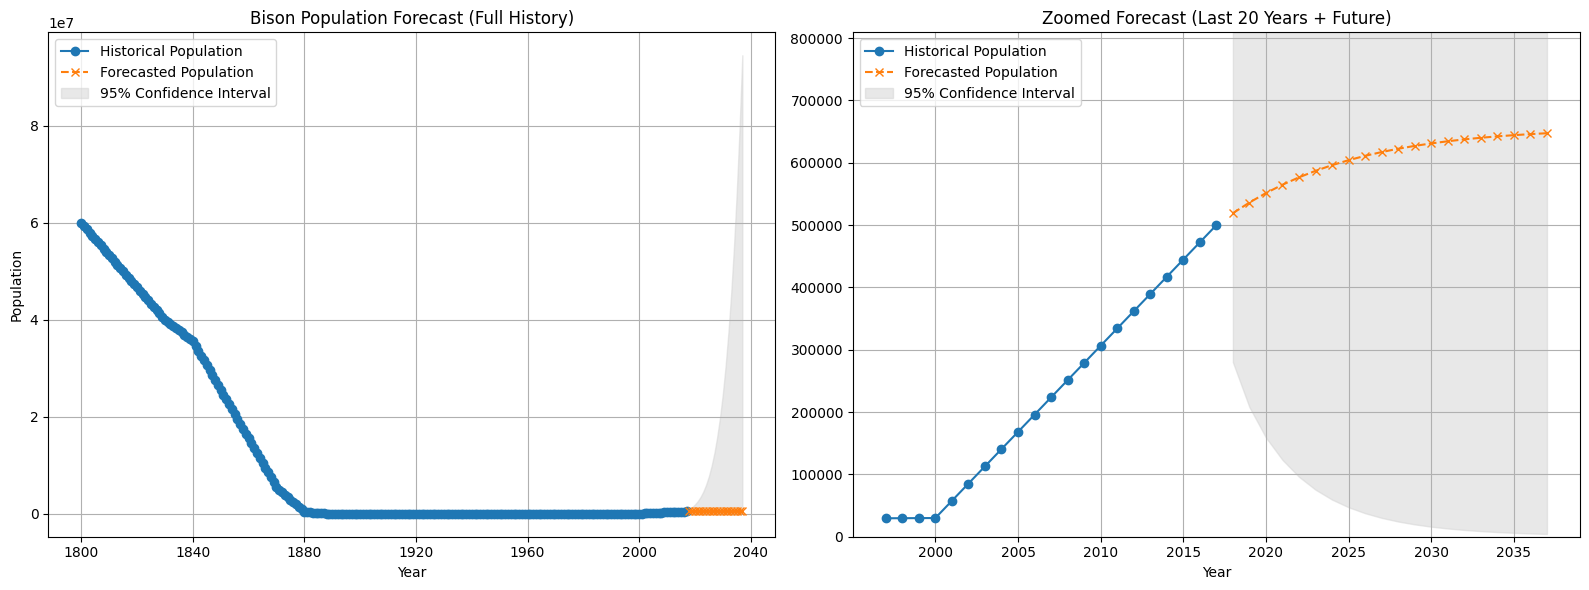

In [64]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=False)

# --- Left: Full historical + forecast (unchanged) ---
axes[0].plot(df.index, df['Population'], label="Historical Population", marker='o')
axes[0].plot(future_df.index, future_df['Forecast_Pop'], label="Forecasted Population", marker='x', linestyle="--")
axes[0].fill_between(future_df.index,
                     future_df['Lower_Pop'],
                     future_df['Upper_Pop'],
                     color='lightgray', alpha=0.5, label="95% Confidence Interval")
axes[0].set_title("Bison Population Forecast (Full History)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Population")
axes[0].legend()
axes[0].grid(True)

# --- Right: Zoomed on recent + forecast (with bounded y-axis) ---
# Choose zoom window: last N years of history + all future
N = 20  # change to taste (e.g., 15)
zoom_start = df.index.max() - pd.DateOffset(years=N)
hist_zoom = df.loc[zoom_start:, 'Population']

# Dynamic y-limit based on realistic scale (ignore huge CI tail)
ymax_zoom = max(hist_zoom.max(), future_df['Forecast_Pop'].max()) * 1.25
ymin_zoom = 0

axes[1].plot(hist_zoom.index, hist_zoom, label="Historical Population", marker='o')
axes[1].plot(future_df.index, future_df['Forecast_Pop'], label="Forecasted Population", marker='x', linestyle="--")

# Clip CI to the zoomed y-range so it doesn't blow up the axis
lower_clip = future_df['Lower_Pop'].clip(lower=ymin_zoom, upper=ymax_zoom)
upper_clip = future_df['Upper_Pop'].clip(lower=ymin_zoom, upper=ymax_zoom)
axes[1].fill_between(future_df.index, lower_clip, upper_clip,
                     color='lightgray', alpha=0.5, label="95% Confidence Interval")

axes[1].set_ylim(ymin_zoom, ymax_zoom)
axes[1].set_title(f"Zoomed Forecast (Last {N} Years + Future)")
axes[1].set_xlabel("Year")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
